## IEOR4004: A Day in Manhattan

Your family is visiting New York City for the first time and have just one day to explore. Starting from their hotel in Midtown, they want to experience key aspects of the city: culture, green space, iconic landmarks, and food. 

You must visit all required locations:
- Greenwich Village
- Columbia University Campus
- Jacqueline Kennedy Onassis Reservoir at the Central Park and the MET
- Restaurants: Where you'll grab food. (there are 2 options, just visit one!)

The map is given here:
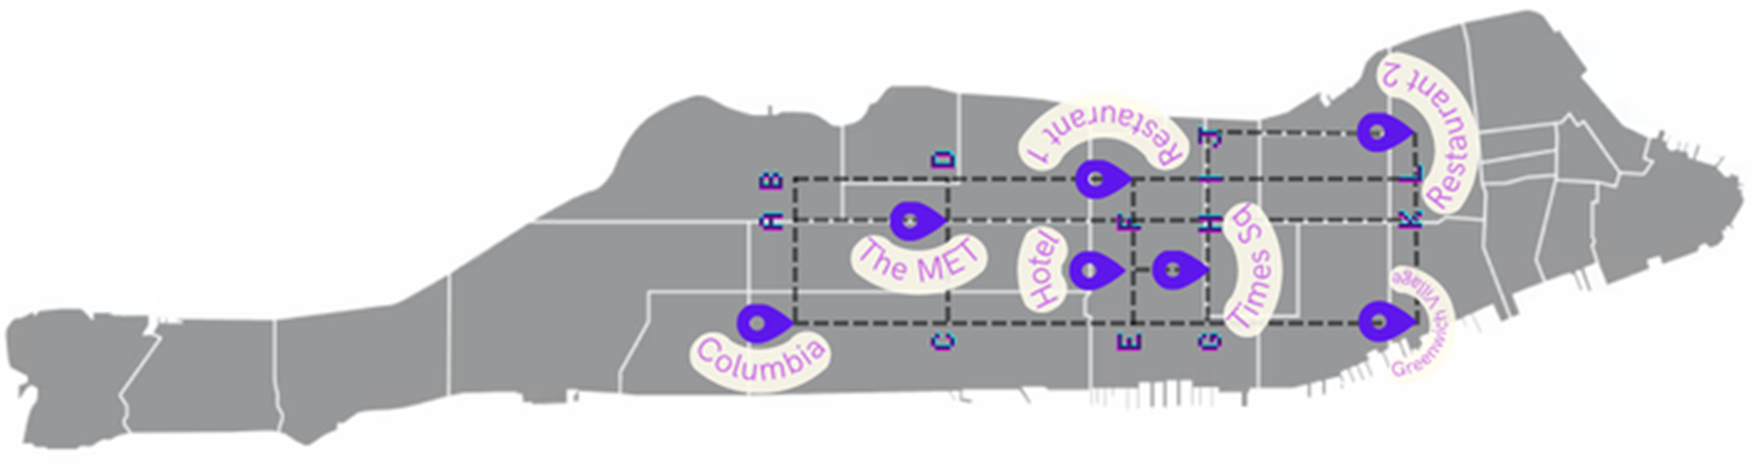

<br> Your task is to plan the most efficient route from their hotel, hitting these key points while avoiding unnecessary detours through tourist-infested areas. Your map is given below. 



In [2]:
import networkx as nx
import matplotlib.pyplot as plt

import gurobipy as gp
from gurobipy import *

In [6]:
locations = {
    # Key locations
    "Columbia": (0,15000),
    "MetMuseum": (1200,9000), 
    "Hotel": (600, 4800),
    "TimesSquare": (600, 3000),
    "GreenwichVillage" : (0,0),

    "Restaurant1": (1700, 4800),
    "Restaurant2": (2000, 0),

    # Grid nodes (aligned with your dashed grid)
    "A": (1200,15000),
    "B": (1700,15000),

    "C": (0, 9000),
    "D": (1700, 9000),

    "E": (0, 4800),
    "F": (1200, 4800),

    "G": (0, 3000),
    "H": (1200, 3000),
    "I": (1700, 3000),
    "J": (2000, 3000),

    "K": (1200, 0),
    "L": (1700, 0)
}

edges = [ ("GreenwichVillage","K" ),("K", "L"), ( "L","Restaurant2"), 
          ( "J","Restaurant2"),("L", "I"), ("K", "H"),("GreenwichVillage","G" ), 
          ("TimesSquare", "G"),("TimesSquare", "H"), ("I", "H"), ("I", "J"),
          ("E", "Hotel"), ("F", "Hotel"), ("F", "Restaurant1"), 
          ("I", "Restaurant1"),("H", "F"), ("TimesSquare", "Hotel"), ("G", "E"),
          ("E", "C"),("F", "MetMuseum"),("Restaurant1", "D"),
          ("D", "MetMuseum"),("MetMuseum", "C"),
          ("C", "Columbia"),("MetMuseum", "A"),("D", "B"),
          ("A", "B"), ("A", "Columbia")]

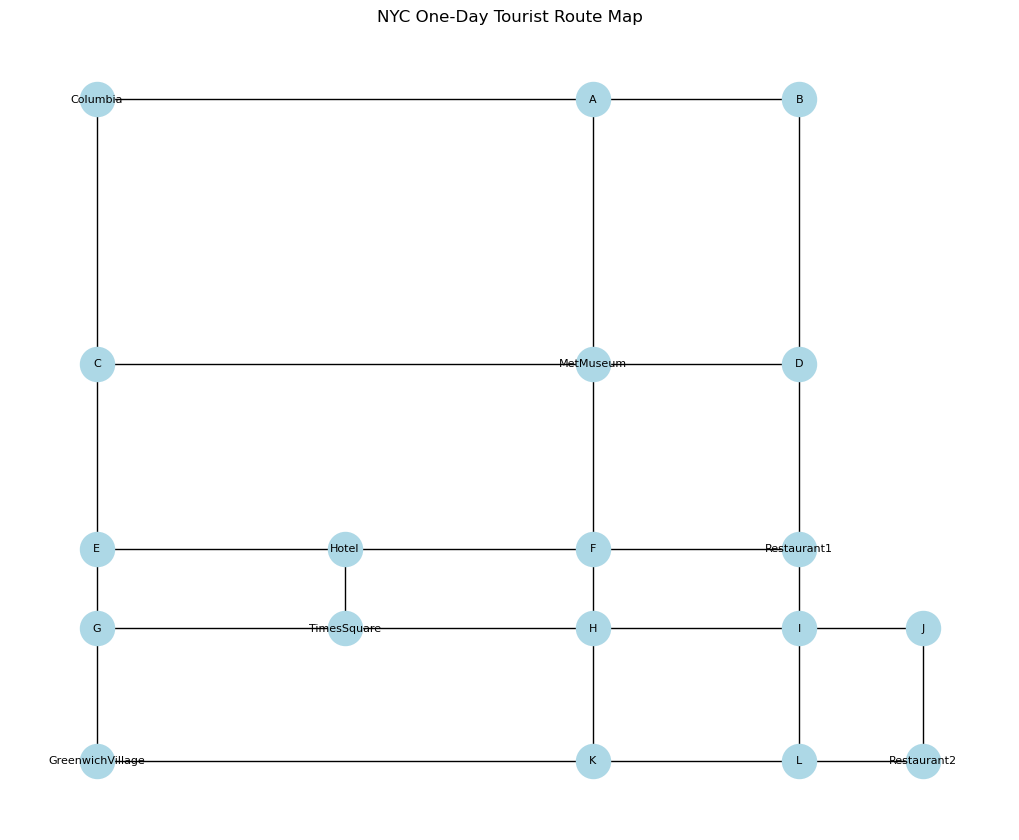

In [7]:
# Create graph
G = nx.Graph()

# Add nodes
for node, pos in locations.items():
    G.add_node(node, pos=pos)

# Add edges
G.add_edges_from(edges)

# Extract positions
pos = nx.get_node_attributes(G, 'pos')

# Draw
plt.figure(figsize=(10, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    node_color='lightblue',
    font_size=8,
    font_color='black'
)

plt.title("NYC One-Day Tourist Route Map")
plt.show()

In [8]:
#List of nodes
nodes = list(locations.keys())

#Number of nodes
num_nodes = len(locations)

# Set of required nodes
required_nodes = {"Columbia", "MetMuseum", "Hotel", "GreenwichVillage"}
non_required_nodes = set(nodes) - set(required_nodes)

#All edges
all_edges = edges + [(b, a) for a, b in edges]

# Filter edges to include only those with at least one node in required_nodes
required_edges = [edge for edge in all_edges if edge[0] in required_nodes or edge[1] in required_nodes]
all_required_edges = required_edges + [(b, a) for a, b in required_edges]

# Filter edges to include only those where neither endpoint is in required_nodes
non_required_edges = [edge for edge in all_edges if edge[0] not in required_nodes and edge[1] not in required_nodes]
all_non_required_edges = non_required_edges + [(b, a) for a, b in non_required_edges]

# Display the filtered edges
# print( f"These are the required edges: {all_required_edges}")
# print( f"These are the non-required edges: {all_non_required_edges}")

#Distance between nodes
dist = {(i, j): abs(pos[i][0] - pos[j][0]) + abs(pos[i][1] - pos[j][1]) for i, j in all_edges}
# print(dist)

If you need to remove certain edges, you can specify them in a similar list
```python
edges_to_remove = [
    # Example: ("Node1", "Node2"),
]
```
Removing specified edges from the graph
```python
G.remove_edges_from(edges_to_remove)
```

**Hint:** You can find all potential cycles using the code below:
```python
# Find all cycles in the graph
all_cycles = list(nx.simple_cycles(G))

# Print all found cycles (subtours)
for cycle in all_cycles:
    print(cycle)
```

If you have an infeasible solution, you can check which one of the constraints are causing the infeasibility by running the code below:

```python
# Check if the model is infeasible
if m.status == GRB.INFEASIBLE:
    print("The model is infeasible; computing the Irreducible Inconsistent Subsystem (IIS):")
    m.computeIIS()  # Compute the IIS
    m.write("model.ilp")  # Write the IIS model to a file for inspection
    print("IIS written to file 'model.ilp'.")
    print("The following constraints and/or bounds are causing the infeasibility:")
    for c in m.getConstrs():
        if c.IISConstr:
            print(f"{c.constrName} is infeasible.")
    for v in m.getVars():
        if v.IISLB > 0 or v.IISUB > 0:
            print(f"Variable bounds on {v.varName} are infeasible.")
```      